In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
foods = pd.read_csv('../data/processed/foods_cleaned.csv')
fao_meat = pd.read_csv('../data/raw/FAOSTAT_meat_prod_2024.csv')


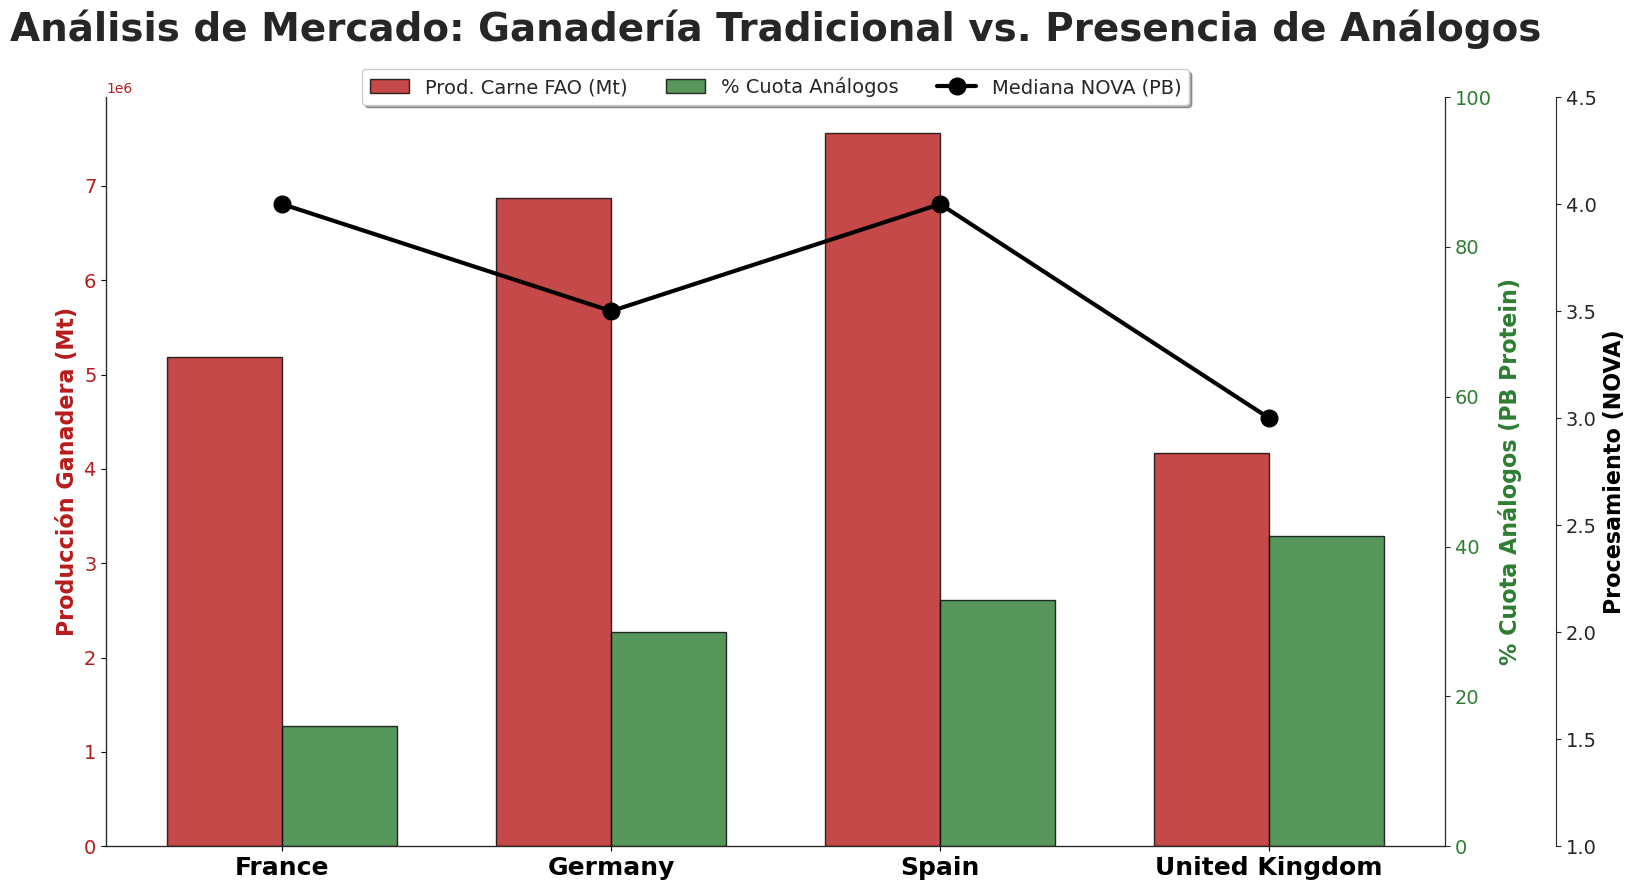

In [4]:
# --- ANÁLISIS ESTRATÉGICO: MERCADO CÁRNICO VS. PRESENCIA VEGETAL ---

# 1. Configuración de Países y Categorías
paises_interes = ['France', 'Spain', 'United Kingdom', 'Germany']
cat_interes = ['meat_fish', 'plant_based_protein']

# 2. Procesamiento de OpenFoodFacts
mask = (foods['main_country'].isin(paises_interes)) & (foods['category_unified'].isin(cat_interes))
subset = foods[mask].copy()

# Agregación y cálculo de cuota de mercado relativa
stats = subset.groupby(['main_country', 'category_unified']).agg(
    conteo=('code', 'count'),
    nova_mediana=('nova_group', 'median')
).unstack(fill_value=0)

# Aplanamos MultiIndex y calculamos el % de penetración de análogos
stats.columns = [f"{c[1]}_{c[0]}" for c in stats.columns]
stats['total_proteina'] = stats['meat_fish_conteo'] + stats['plant_based_protein_conteo']
stats['pct_analogos'] = (stats['plant_based_protein_conteo'] / stats['total_proteina']) * 100

# 3. Integración con FAO (Asegurando nombres de países)
fao_clean = fao_meat[fao_meat['Item'] == 'Meat, Total'][['Area', 'Value']].copy()
df_mkt = pd.merge(stats.reset_index(), fao_clean, left_on='main_country', right_on='Area')

# 4. Visualización de Triple Eje (Estilo Económico)
fig, ax1 = plt.subplots(figsize=(16, 9))
sns.set_style("white")

x = np.arange(len(df_mkt))
width = 0.35

# EJE 1: Producción FAO (Toneladas de Carne) - BARRAS ROJAS
color_fao = '#B71C1C' # Rojo oscuro (Carne)
rects1 = ax1.bar(x - width/2, df_mkt['Value'], width, label='Prod. Carne FAO (Mt)', color=color_fao, alpha=0.8, edgecolor='black')
ax1.set_ylabel('Producción Ganadera (Mt)', fontsize=16, fontweight='bold', color=color_fao)
ax1.tick_params(axis='y', labelcolor=color_fao, labelsize=14)

# EJE 2: Cuota de Análogos (PB Protein) - BARRAS VERDES
ax2 = ax1.twinx()
color_pb = '#2E7D32' # Verde bosque (Vegetal)
rects2 = ax2.bar(x + width/2, df_mkt['pct_analogos'], width, label='% Cuota Análogos', color=color_pb, alpha=0.8, edgecolor='black')
ax2.set_ylabel('% Cuota Análogos (PB Protein)', fontsize=16, fontweight='bold', color=color_pb)
ax2.tick_params(axis='y', labelcolor=color_pb, labelsize=14)
ax2.set_ylim(0, 100)

# EJE 3: Grado de Procesamiento (NOVA) - LÍNEA NEGRA
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 80)) # Desplazamiento del tercer eje
line3 = ax3.plot(df_mkt['main_country'], df_mkt['plant_based_protein_nova_mediana'], 
                 color='black', marker='o', markersize=12, linewidth=3, label='Mediana NOVA (PB)')
ax3.set_ylabel('Procesamiento (NOVA)', fontsize=16, fontweight='bold', color='black')
ax3.set_ylim(1, 4.5)
ax3.tick_params(axis='y', labelsize=14)

# Estética y Títulos
plt.title('Análisis de Mercado: Ganadería Tradicional vs. Presencia de Análogos', 
          fontsize=28, fontweight='bold', pad=40)

ax1.set_xticks(x)
ax1.set_xticklabels(df_mkt['main_country'], fontsize=18, fontweight='bold')

# Leyenda unificada superior
all_h, all_l = [], []
for ax in [ax1, ax2, ax3]:
    h, l = ax.get_legend_handles_labels()
    all_h.extend(h)
    all_l.extend(l)
ax1.legend(all_h, all_l, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, fontsize=14, frameon=True, shadow=True)

sns.despine(right=False)
plt.tight_layout()
plt.savefig('../images/04_h04/4.1_Carne_Analogos_Procesado_Mediana.png', bbox_inches='tight', dpi=300)
plt.show()

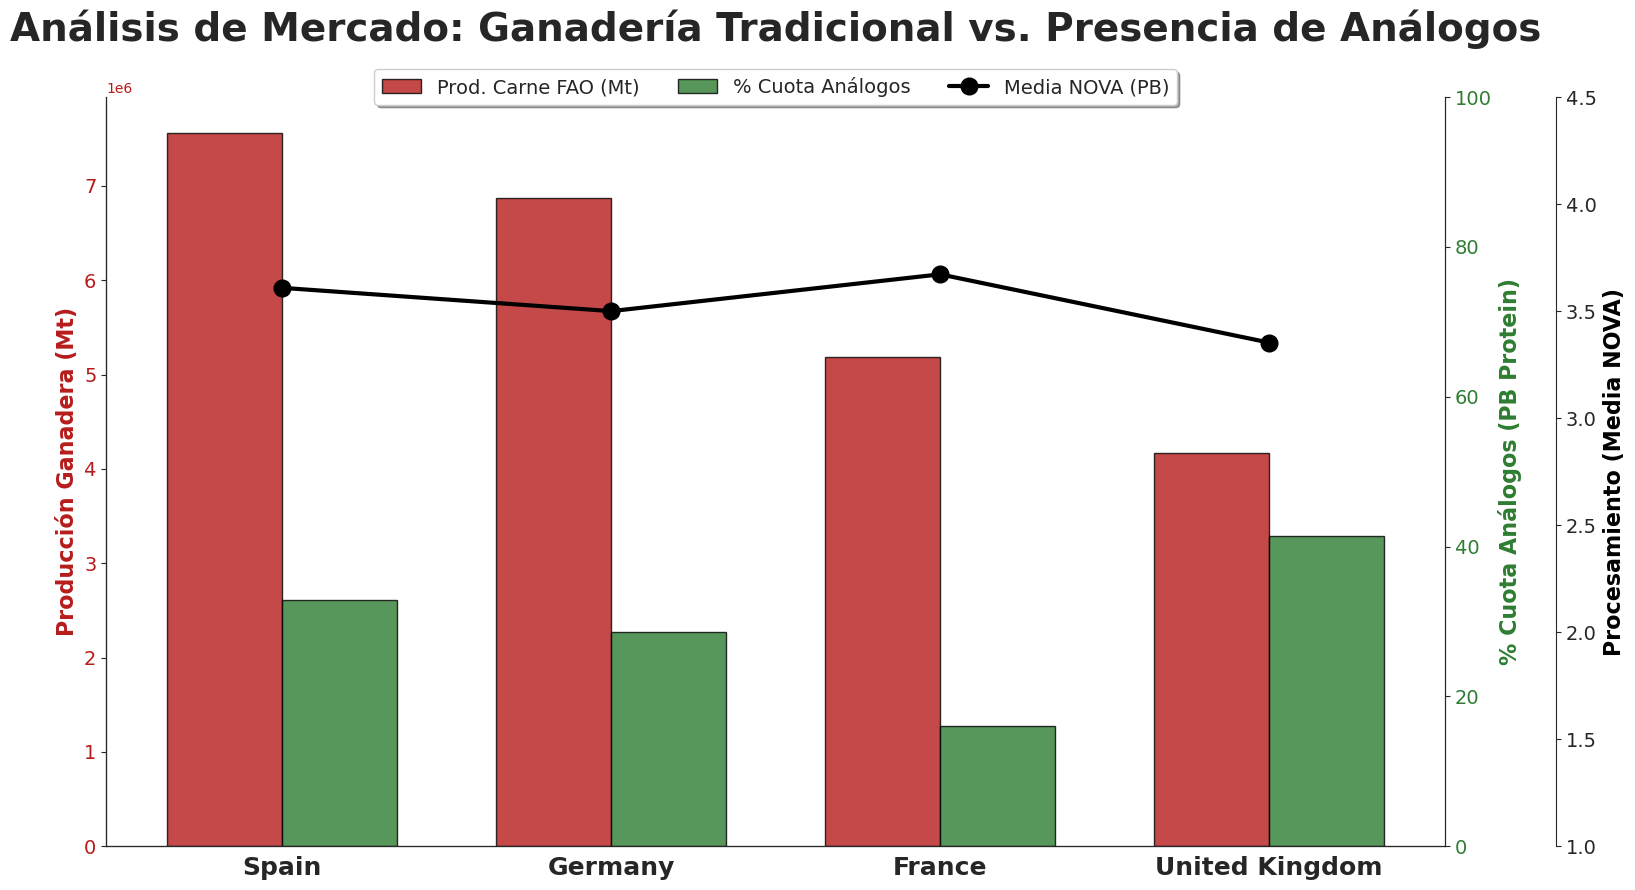

In [5]:
# --- ANÁLISIS ESTRATÉGICO: MERCADO CÁRNICO VS. PRESENCIA VEGETAL ---

# 1. Configuración de Países y Categorías (Orden específico solicitado)
orden_paises = ['Spain', 'Germany', 'France', 'United Kingdom']
cat_interes = ['meat_fish', 'plant_based_protein']

# 2. Procesamiento de OpenFoodFacts
mask = (foods['main_country'].isin(orden_paises)) & (foods['category_unified'].isin(cat_interes))
subset = foods[mask].copy()

# Agregación: CALCULANDO LA MEDIA (mean)
stats = subset.groupby(['main_country', 'category_unified']).agg(
    conteo=('code', 'count'),
    nova_media=('nova_group', 'mean')
).unstack(fill_value=0)

# Aplanamos MultiIndex
stats.columns = [f"{c[1]}_{c[0]}" for c in stats.columns]
stats['total_proteina'] = stats['meat_fish_conteo'] + stats['plant_based_protein_conteo']
stats['pct_analogos'] = (stats['plant_based_protein_conteo'] / stats['total_proteina']) * 100

# 3. Integración con FAO
fao_clean = fao_meat[fao_meat['Item'] == 'Meat, Total'][['Area', 'Value']].copy()
df_mkt = pd.merge(stats.reset_index(), fao_clean, left_on='main_country', right_on='Area')

# --- REORDENAMIENTO EXPLÍCITO ---
# Convertimos main_country en categoría con el orden deseado para asegurar la posición en el eje X
df_mkt['main_country'] = pd.Categorical(df_mkt['main_country'], categories=orden_paises, ordered=True)
df_mkt = df_mkt.sort_values('main_country')

# 4. Visualización de Triple Eje
fig, ax1 = plt.subplots(figsize=(16, 9))
sns.set_style("white")

x = np.arange(len(df_mkt))
width = 0.35

# EJE 1: Producción FAO (Barras Rojas)
color_fao = '#B71C1C' 
ax1.bar(x - width/2, df_mkt['Value'], width, label='Prod. Carne FAO (Mt)', color=color_fao, alpha=0.8, edgecolor='black')
ax1.set_ylabel('Producción Ganadera (Mt)', fontsize=16, fontweight='bold', color=color_fao)
ax1.tick_params(axis='y', labelcolor=color_fao, labelsize=14)

# EJE 2: Cuota de Análogos (Barras Verdes)
ax2 = ax1.twinx()
color_pb = '#2E7D32' 
ax2.bar(x + width/2, df_mkt['pct_analogos'], width, label='% Cuota Análogos', color=color_pb, alpha=0.8, edgecolor='black')
ax2.set_ylabel('% Cuota Análogos (PB Protein)', fontsize=16, fontweight='bold', color=color_pb)
ax2.tick_params(axis='y', labelcolor=color_pb, labelsize=14)
ax2.set_ylim(0, 100)

# EJE 3: Grado de Procesamiento (Línea Negra - MEDIA)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 80)) 
ax3.plot(df_mkt['main_country'].astype(str), df_mkt['plant_based_protein_nova_media'], 
         color='black', marker='o', markersize=12, linewidth=3, label='Media NOVA (PB)')
ax3.set_ylabel('Procesamiento (Media NOVA)', fontsize=16, fontweight='bold', color='black')
ax3.set_ylim(1, 4.5)
ax3.tick_params(axis='y', labelsize=14)

# Estética y Títulos
plt.title('Análisis de Mercado: Ganadería Tradicional vs. Presencia de Análogos', 
          fontsize=28, fontweight='bold', pad=40)

ax1.set_xticks(x)
ax1.set_xticklabels(orden_paises, fontsize=18, fontweight='bold')

# Leyenda unificada
all_h, all_l = [], []
for ax in [ax1, ax2, ax3]:
    h, l = ax.get_legend_handles_labels()
    all_h.extend(h)
    all_l.extend(l)
ax1.legend(all_h, all_l, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, fontsize=14, frameon=True, shadow=True)

sns.despine(right=False)
plt.tight_layout()
plt.savefig('../images/04_h04/4.2_Carne_Analogos_Procesado_Media.png', bbox_inches='tight', dpi=300)
plt.show()


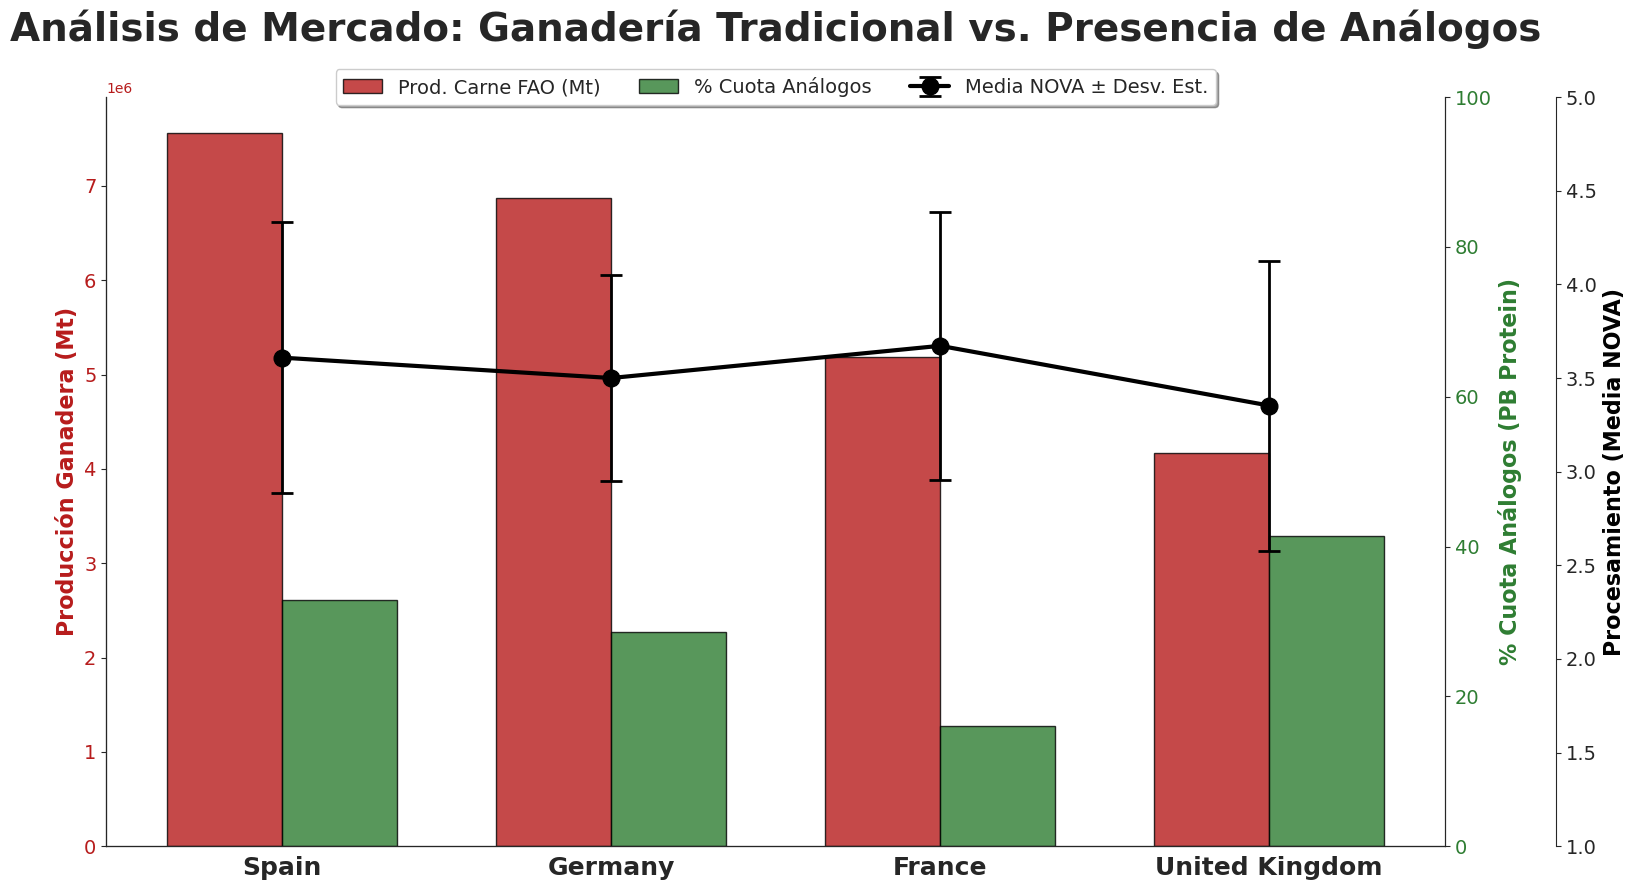

In [6]:
# --- ANÁLISIS ESTRATÉGICO: MERCADO CÁRNICO VS. PRESENCIA VEGETAL ---

# 1. Configuración de Países y Categorías
orden_paises = ['Spain', 'Germany', 'France', 'United Kingdom']
cat_interes = ['meat_fish', 'plant_based_protein']

# 2. Procesamiento de OpenFoodFacts
mask = (foods['main_country'].isin(orden_paises)) & (foods['category_unified'].isin(cat_interes))
subset = foods[mask].copy()

# Agregación: CALCULANDO MEDIA Y DESVIACIÓN ESTÁNDAR
stats = subset.groupby(['main_country', 'category_unified']).agg(
    conteo=('code', 'count'),
    nova_media=('nova_group', 'mean'),
    nova_std=('nova_group', 'std') # Añadimos la desviación estándar para las barras de error
).unstack(fill_value=0)

# Aplanamos MultiIndex
stats.columns = [f"{c[1]}_{c[0]}" for c in stats.columns]
stats['total_proteina'] = stats['meat_fish_conteo'] + stats['plant_based_protein_conteo']
stats['pct_analogos'] = (stats['plant_based_protein_conteo'] / stats['total_proteina']) * 100

# 3. Integración con FAO
fao_clean = fao_meat[fao_meat['Item'] == 'Meat, Total'][['Area', 'Value']].copy()
df_mkt = pd.merge(stats.reset_index(), fao_clean, left_on='main_country', right_on='Area')

# Reordenamiento
df_mkt['main_country'] = pd.Categorical(df_mkt['main_country'], categories=orden_paises, ordered=True)
df_mkt = df_mkt.sort_values('main_country')

# 4. Visualización de Triple Eje
fig, ax1 = plt.subplots(figsize=(16, 9))
sns.set_style("white")

x = np.arange(len(df_mkt))
width = 0.35

# EJE 1: Producción FAO (Barras Rojas)
color_fao = '#B71C1C' 
ax1.bar(x - width/2, df_mkt['Value'], width, label='Prod. Carne FAO (Mt)', color=color_fao, alpha=0.8, edgecolor='black')
ax1.set_ylabel('Producción Ganadera (Mt)', fontsize=16, fontweight='bold', color=color_fao)
ax1.tick_params(axis='y', labelcolor=color_fao, labelsize=14)

# EJE 2: Cuota de Análogos (Barras Verdes)
ax2 = ax1.twinx()
color_pb = '#2E7D32' 
ax2.bar(x + width/2, df_mkt['pct_analogos'], width, label='% Cuota Análogos', color=color_pb, alpha=0.8, edgecolor='black')
ax2.set_ylabel('% Cuota Análogos (PB Protein)', fontsize=16, fontweight='bold', color=color_pb)
ax2.tick_params(axis='y', labelcolor=color_pb, labelsize=14)
ax2.set_ylim(0, 100)

# EJE 3: Grado de Procesamiento (Línea Negra + BARRAS DE ERROR)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 80)) 

# Usamos errorbar para incluir la desviación estándar
ax3.errorbar(
    x=df_mkt['main_country'].astype(str), 
    y=df_mkt['plant_based_protein_nova_media'],
    yerr=df_mkt['plant_based_protein_nova_std'], # Aquí se asigna el error
    color='black', 
    marker='o', 
    markersize=12, 
    linewidth=3, 
    capsize=8,      # Ancho de las líneas horizontales del error
    capthick=2, 
    elinewidth=2,   # Grosor de la línea de error
    label='Media NOVA ± Desv. Est.'
)

ax3.set_ylabel('Procesamiento (Media NOVA)', fontsize=16, fontweight='bold', color='black')
ax3.set_ylim(1, 5) # Ajustado un poco para que el error no se corte
ax3.tick_params(axis='y', labelsize=14)

# Estética y Títulos
plt.title('Análisis de Mercado: Ganadería Tradicional vs. Presencia de Análogos', 
          fontsize=28, fontweight='bold', pad=40)

ax1.set_xticks(x)
ax1.set_xticklabels(orden_paises, fontsize=18, fontweight='bold')

# Leyenda unificada
all_h, all_l = [], []
for ax in [ax1, ax2, ax3]:
    h, l = ax.get_legend_handles_labels()
    all_h.extend(h)
    all_l.extend(l)
ax1.legend(all_h, all_l, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3, fontsize=14, frameon=True, shadow=True)

sns.despine(right=False)
plt.tight_layout()
plt.savefig('../images/04_h04/4.3_Carne_Analogos_Procesado_Media-desv.png', bbox_inches='tight', dpi=300)
plt.show()

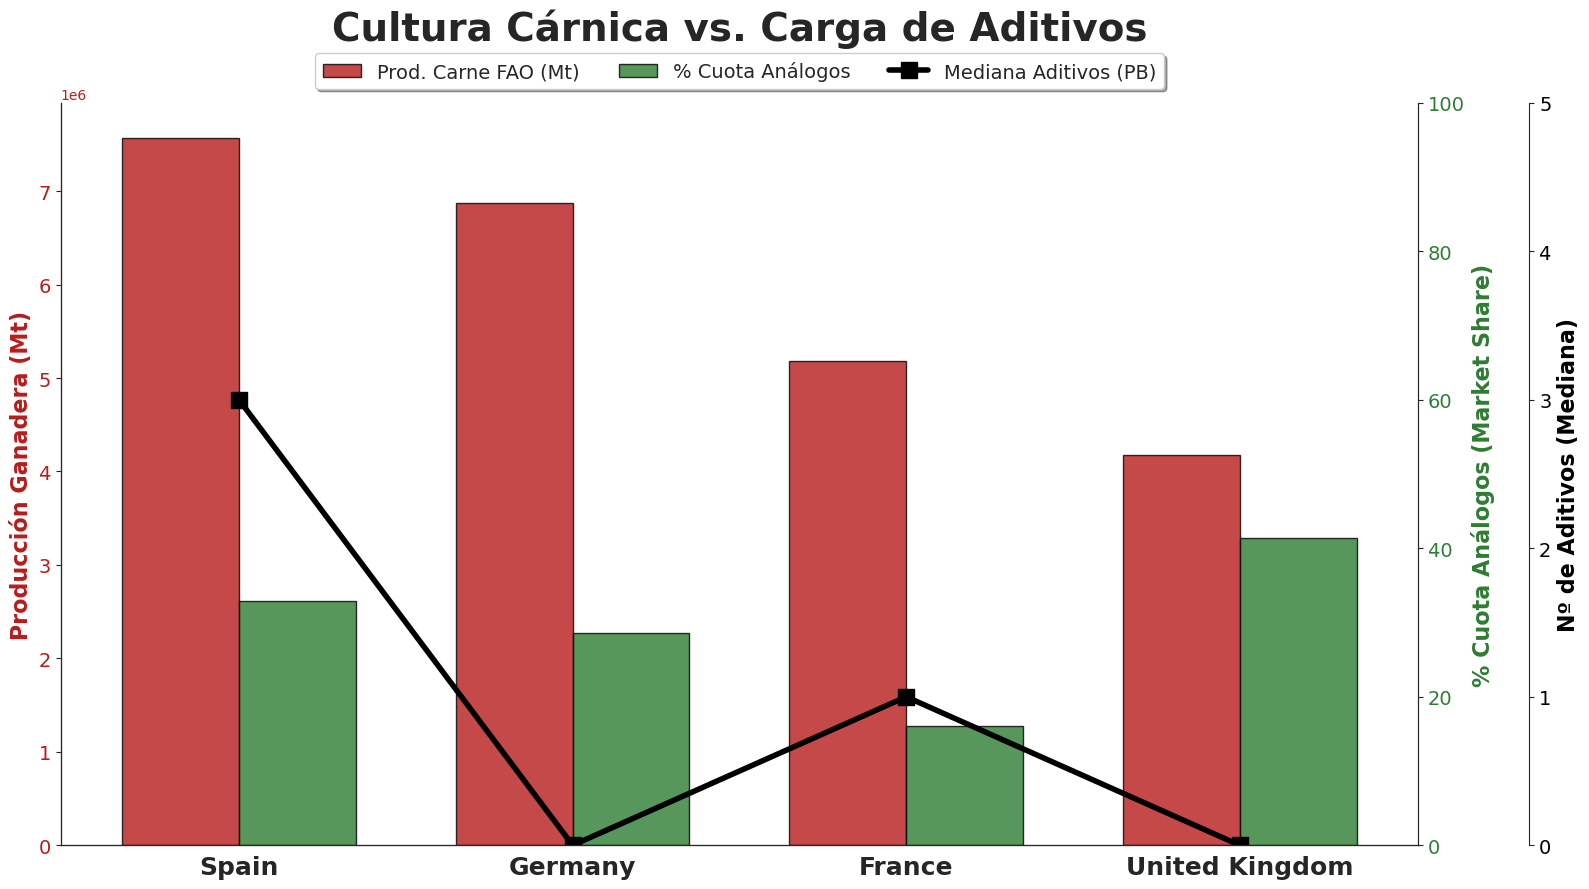

In [7]:
# --- ANÁLISIS ESTRATÉGICO: PRODUCCIÓN vs. PENETRACIÓN vs. ADITIVOS (MEDIANA) ---

# 1. Configuración de Países y Categorías
orden_paises = ['Spain', 'Germany', 'France', 'United Kingdom']
cat_interes = ['meat_fish', 'plant_based_protein']

# 2. Procesamiento de OpenFoodFacts
mask = (foods['main_country'].isin(orden_paises)) & (foods['category_unified'].isin(cat_interes))
subset = foods[mask].copy()

# Agregación: CALCULANDO LA MEDIANA DE ADITIVOS (Solo para PB)
stats = subset.groupby(['main_country', 'category_unified']).agg(
    conteo=('code', 'count'),
    additives_mediana=('additive_count', 'median')
).unstack(fill_value=0)

# Aplanamos MultiIndex y calculamos % de penetración
stats.columns = [f"{c[1]}_{c[0]}" for c in stats.columns]
stats['total_proteina'] = stats['meat_fish_conteo'] + stats['plant_based_protein_conteo']
stats['pct_analogos'] = (stats['plant_based_protein_conteo'] / stats['total_proteina']) * 100

# 3. Integración con FAO
fao_clean = fao_meat[fao_meat['Item'] == 'Meat, Total'][['Area', 'Value']].copy()
df_mkt = pd.merge(stats.reset_index(), fao_clean, left_on='main_country', right_on='Area')

# Reordenamiento explícito
df_mkt['main_country'] = pd.Categorical(df_mkt['main_country'], categories=orden_paises, ordered=True)
df_mkt = df_mkt.sort_values('main_country')

# 4. Visualización de Triple Eje
fig, ax1 = plt.subplots(figsize=(16, 9))
sns.set_style("white")

x = np.arange(len(df_mkt))
width = 0.35

# EJE 1: Producción FAO (Barras Rojas)
color_fao = '#B71C1C' 
ax1.bar(x - width/2, df_mkt['Value'], width, label='Prod. Carne FAO (Mt)', color=color_fao, alpha=0.8, edgecolor='black')
ax1.set_ylabel('Producción Ganadera (Mt)', fontsize=16, fontweight='bold', color=color_fao)
ax1.tick_params(axis='y', labelcolor=color_fao, labelsize=14)

# EJE 2: Cuota de Análogos (Barras Verdes)
ax2 = ax1.twinx()
color_pb = '#2E7D32' 
ax2.bar(x + width/2, df_mkt['pct_analogos'], width, label='% Cuota Análogos', color=color_pb, alpha=0.8, edgecolor='black')
ax2.set_ylabel('% Cuota Análogos (Market Share)', fontsize=16, fontweight='bold', color=color_pb)
ax2.tick_params(axis='y', labelcolor=color_pb, labelsize=14)
ax2.set_ylim(0, 100)

# EJE 3: Complejidad Química (Línea Azul - MEDIANA)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 80)) 
color_add = "#000000"

ax3.plot(df_mkt['main_country'].astype(str), df_mkt['plant_based_protein_additives_mediana'], 
         color=color_add, marker='s', markersize=12, linewidth=4, label='Mediana Aditivos (PB)')

ax3.set_ylabel('Nº de Aditivos (Mediana)', fontsize=16, fontweight='bold', color=color_add)
# Escala ajustada para que la línea se vea claramente
max_y = df_mkt['plant_based_protein_additives_mediana'].max()
ax3.set_ylim(0, max_y + 2) 
ax3.tick_params(axis='y', labelcolor=color_add, labelsize=14)

# Estética y Títulos
plt.title('Cultura Cárnica vs. Carga de Aditivos', 
          fontsize=28, fontweight='bold', pad=45)

ax1.set_xticks(x)
ax1.set_xticklabels(orden_paises, fontsize=18, fontweight='bold')

# Leyenda unificada
all_h, all_l = [], []
for ax in [ax1, ax2, ax3]:
    h, l = ax.get_legend_handles_labels()
    all_h.extend(h)
    all_l.extend(l)
ax1.legend(all_h, all_l, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=3, fontsize=14, frameon=True, shadow=True)

sns.despine(right=False)
plt.tight_layout()
plt.savefig('../images/04_h04/4.4_Carne_Analogos_Procesado_Mediana-aditivos.png', bbox_inches='tight', dpi=300)
plt.show()

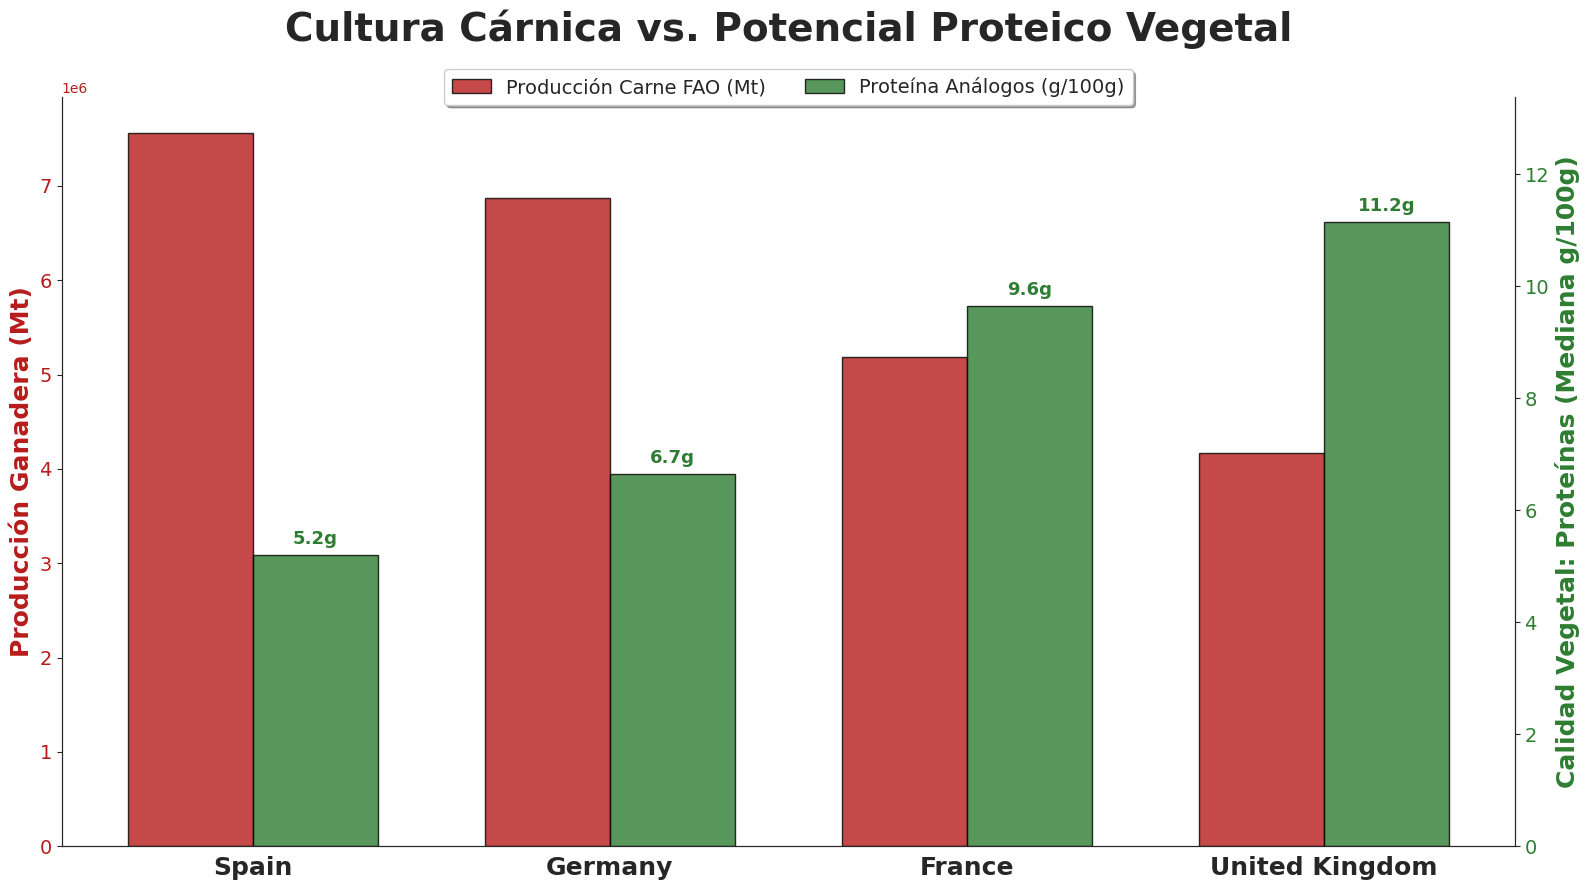

In [8]:
# --- COMPARATIVA: CULTURA CÁRNICA (FAO) VS. DENSIDAD PROTEICA VEGETAL (PB) ---

# 1. Preparación de datos de Proteína (MEDIANA de Análogos Vegetales)
orden_paises = ['Spain', 'Germany', 'France', 'United Kingdom']

df_pb_prot = foods[
    (foods['main_country'].isin(orden_paises)) & 
    (foods['category_unified'] == 'plant_based_protein')
].groupby('main_country')['proteins_100g'].median().reset_index() # CAMBIADO A MEDIAN

# 2. Preparación de datos FAO (Producción Total)
fao_total = fao_meat[fao_meat['Item'] == 'Meat, Total'][['Area', 'Value']].copy()

# 3. Combinar y Ordenar según el orden solicitado
df_comp = pd.merge(df_pb_prot, fao_total, left_on='main_country', right_on='Area')
df_comp['main_country'] = pd.Categorical(df_comp['main_country'], categories=orden_paises, ordered=True)
df_comp = df_comp.sort_values('main_country')

# 4. Visualización de Doble Eje
fig, ax1 = plt.subplots(figsize=(16, 9))
sns.set_style("white")

x = np.arange(len(df_comp))
width = 0.35

# EJE 1: Producción Cárnica (Barras Rojas)
color_fao = '#B71C1C'
bar1 = ax1.bar(x - width/2, df_comp['Value'], width, label='Producción Carne FAO (Mt)', 
               color=color_fao, alpha=0.8, edgecolor='black')
ax1.set_ylabel('Producción Ganadera (Mt)', fontsize=18, fontweight='bold', color=color_fao)
ax1.tick_params(axis='y', labelcolor=color_fao, labelsize=14)

# EJE 2: Densidad Proteica Vegetal (Barras Verdes - MEDIANA)
ax2 = ax1.twinx()
color_pb = '#2E7D32'
bar2 = ax2.bar(x + width/2, df_comp['proteins_100g'], width, label='Proteína Análogos (g/100g)', 
               color=color_pb, alpha=0.8, edgecolor='black')
ax2.set_ylabel('Calidad Vegetal: Proteínas (Mediana g/100g)', fontsize=18, fontweight='bold', color=color_pb)
ax2.tick_params(axis='y', labelcolor=color_pb, labelsize=14)
ax2.set_ylim(0, df_comp['proteins_100g'].max() * 1.2)

# Estética y Etiquetas
plt.title("Cultura Cárnica vs. Potencial Proteico Vegetal", fontsize=28, fontweight='bold', pad=40)
ax1.set_xticks(x)
ax1.set_xticklabels(orden_paises, fontsize=18, fontweight='bold')

# Anotaciones en las barras
for i, rect in enumerate(bar2):
    height = rect.get_height()
    ax2.annotate(f'{height:.1f}g', 
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 5), textcoords="offset points",
                ha='center', va='bottom', fontsize=13, fontweight='bold', color=color_pb)

# Leyenda unificada
lines = [bar1, bar2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, fontsize=14, frameon=True, shadow=True)

sns.despine(right=False)
plt.tight_layout()
plt.savefig('../images/04_h04/4.5_Cultura_vs_Proteina_PB_Mediana.png', bbox_inches='tight', dpi=300)
plt.show()